# Glovo Hourly Order Forecasting — Modelling (v2)

**AI Disclosure:** AI tools were used to help structure and improve this notebook. All outputs have been reviewed, validated, and adapted by the students. The AI prompt history is shared as part of the submission.

---

## From EDA to modelling decisions

The EDA (see `EDA.ipynb`) identified five patterns that directly shape our choices here:
the ~25% zero-order overnight hours motivate the `zero_mask` routing and Tweedie objective;
the right-skewed distribution rules out Gaussian loss; the upward trend motivates the `trend`
feature; the strong weekly and daily cycles make `lag_168`, `hour`, and `dayofweek` the most
informative features; and the sub-one-year data range means we exclude yearly seasonality from
Prophet. Missing slots (3 dates, hours 0–5) are filled with 0 to prevent NaN cascades in lag
features.

Two corrections vs the first pass: **`zero_mask` is built from `lag_168` only**, not from
`lag_168 AND lag_24`. The forecast horizon here is a full week (168 hours) — `lag_168` always
points 168 hours back into real, already-observed history for *every* hour of that horizon,
but `lag_24` only does so for the first 24 hours; beyond that it would point inside the still
-unknown forecast window itself. Using it for routing or as a model feature looked fine in
walk-forward CV (where the "future" val data already exists) but silently broke for the real
forecast, where those hours are genuinely unknown. `lag_24` has been dropped entirely as a
result. Second, an **`is_holiday`** flag (Spanish/Catalan public holidays) was added, since two
of the five CV folds land on the Christmas/New Year period, which deviates from the ordinary
weekly cycle the lag features otherwise rely on.

## 0. Imports and config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_PATH      = '../data/train_data.csv'
TEST_MOCK_PATH = '../data/test_data_mock.csv'
OUTPUT_PATH    = '../data/predictions.csv'
FORECAST_START = pd.Timestamp('2022-01-24 00:00:00')
FORECAST_END   = pd.Timestamp('2022-01-30 23:00:00')
HORIZON        = 168   # 7 days × 24 hours
N_FOLDS        = 5

# Threshold below which lag values are treated as 'zero-order slot'
# (hours 0-6 are consistently 0 or 1, active hours are typically > 10)
ZERO_LAG_THRESHOLD = 2

## 1. Load and prepare data

In [2]:
df = pd.read_csv(DATA_PATH)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

# Fill the three known 6-hour early-morning gaps with 0
full_index = pd.date_range(df['time'].min(), df['time'].max(), freq='h')
df = df.set_index('time').reindex(full_index).rename_axis('time').reset_index()
df['orders'] = df['orders'].fillna(0.0)
df['city']   = df['city'].ffill()

print(f"Rows: {len(df)}")
print(f"Range: {df['time'].min()} to {df['time'].max()}")
print(f"Zero-order hours: {(df['orders'] == 0).sum()} ({(df['orders'] == 0).mean()*100:.1f}%)")
print(f"Orders by hour-of-day (mean):")
print(df.groupby(df['time'].dt.hour)['orders'].mean().round(1).to_string())

Rows: 8568
Range: 2021-02-01 00:00:00 to 2022-01-23 23:00:00
Zero-order hours: 2726 (31.8%)
Orders by hour-of-day (mean):
time
0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
5       0.0
6       0.7
7       1.4
8      10.3
9      30.6
10     33.4
11     29.2
12     73.3
13    214.5
14    180.0
15     94.5
16     48.4
17     44.1
18     50.6
19    104.1
20    278.7
21    384.7
22    166.6
23      0.0


## 2. Feature engineering

Building on the EDA findings (upward trend, strong daily seasonality with lunch/dinner peaks, weekly pattern with weekends higher) and the class slides on **lag features, seasonal dummies, and trend terms**.

Key addition: **`zero_mask`** — a binary flag that is 1 when `lag_168` is at or below the zero threshold. This identifies hours that were structurally zero last week, so we can safely predict 0 and avoid the SMAPE blowup.

We deliberately do **not** also require `lag_24 ≤ threshold`. The forecast horizon is 168 hours (a full week), and `lag_24` only reaches into real observed history for the first 24 hours of that horizon — for hours 25–168 it would point at a still-unknown forecast-window value. That made the original `lag_168 AND lag_24` rule look fine in walk-forward CV (where the val "future" already exists in the historical data) but it broke for the real forecast: `lag_24` is NaN for most of the week, so the AND-condition silently failed and routed those hours to the raw model instead of the safe naive fallback. `lag_168`, by contrast, always reaches exactly 168 hours back — i.e. always into real training history — for every hour of the horizon, making it the only safe single-lag signal at this forecast distance. For the same reason, `lag_24` is dropped from the feature set entirely rather than just from `zero_mask`.

We also add **`is_holiday`** (Spanish/Catalan public holidays observed in Barcelona) since the lag/seasonal features assume an ordinary weekly cycle, which holiday dates — including the Christmas/New Year period covered by two of our five CV folds — don't follow.

In [3]:
# Spanish/Catalan public holidays observed in Barcelona during the data range.
# Food-delivery demand on these dates deviates from the ordinary weekly cycle,
# which the lag/seasonal features alone don't capture.
HOLIDAYS = pd.to_datetime([
    '2021-01-01', '2021-01-06', '2021-04-02', '2021-04-05', '2021-05-01',
    '2021-06-24', '2021-08-15', '2021-09-11', '2021-09-24', '2021-10-12',
    '2021-11-01', '2021-12-06', '2021-12-08', '2021-12-25', '2021-12-26',
    '2022-01-01', '2022-01-06',
])

def add_features(df):
    df = df.copy()
    df['hour']          = df['time'].dt.hour
    df['dayofweek']     = df['time'].dt.dayofweek   # 0=Mon, 6=Sun
    df['week']          = df['time'].dt.isocalendar().week.astype(int)
    df['trend']         = np.arange(len(df))        # linear time index
    df['is_weekend']    = (df['dayofweek'] >= 4).astype(int)  # Fri-Sun higher demand
    df['is_holiday']    = df['time'].dt.normalize().isin(HOLIDAYS).astype(int)

    # Lag features — NaN for first rows, dropped before training.
    # lag_24 is intentionally NOT included: for a 168-hour-ahead forecast it only
    # reaches into real history for the first 24 hours of the horizon (see Section 2).
    df['lag_168']       = df['orders'].shift(168)   # same hour last week
    df['lag_336']       = df['orders'].shift(336)   # same hour 2 weeks ago
    df['roll_168_mean'] = df['orders'].shift(168).rolling(168).mean()
    df['roll_336_mean'] = df['orders'].shift(168).rolling(336).mean()

    # Zero-mask: True when last week's same hour was a zero-order slot.
    # Only lag_168 is used — it always points 168 hours back into real training
    # history for every hour of the 168-hour forecast horizon, unlike lag_24.
    # When lag_168 is NaN (first week), treat as NOT a zero-slot (conservative).
    df['zero_mask'] = (df['lag_168'].fillna(999) <= ZERO_LAG_THRESHOLD).astype(int)

    return df

df = add_features(df)

print(f"Zero-mask proportion: {df['zero_mask'].mean()*100:.1f}% of all hours")
print(f"Zero-mask by hour-of-day:")
print(df.groupby('hour')['zero_mask'].mean().round(2).to_string())

Zero-mask proportion: 36.1% of all hours
Zero-mask by hour-of-day:
hour
0     0.98
1     0.98
2     0.98
3     0.98
4     0.98
5     0.98
6     0.93
7     0.87
8     0.00
9     0.00
10    0.00
11    0.00
12    0.00
13    0.00
14    0.00
15    0.00
16    0.00
17    0.00
18    0.00
19    0.00
20    0.00
21    0.00
22    0.00
23    0.98


## 3. Evaluation utilities

**SMAPE** is the primary metric (grading criterion). When both actual and predicted are 0, contribution is 0 (no division-by-zero).

In [4]:
def smape(actual, pred):
    actual = np.array(actual, dtype=float)
    pred   = np.array(pred,   dtype=float)
    denom  = np.abs(actual) + np.abs(pred)
    return np.mean(np.where(denom == 0, 0.0, 2 * np.abs(actual - pred) / denom)) * 100

def mse(actual, pred):
    return np.mean((np.array(actual) - np.array(pred)) ** 2)

def evaluate(actual, pred, label=''):
    pred_clipped = np.maximum(pred, 0)
    m = mse(actual, pred_clipped)
    s = smape(actual, pred_clipped)
    if label:
        print(f"{label:45s}  MSE: {m:8.1f}  SMAPE: {s:.2f}%")
    return {'mse': m, 'smape': s}

## 4. Walk-forward cross-validation

The production scenario: every Sunday at 23:59 we train on all available history and forecast the next full week. We simulate this with 5 sequential folds — always train on past, validate on future. This is the correct approach covered in class.

In [5]:
def get_cv_folds(df, n_folds=N_FOLDS):
    folds = []
    last  = df['time'].max()
    for k in range(n_folds, 0, -1):
        val_end   = last - pd.Timedelta(hours=(k - 1) * HORIZON)
        val_start = val_end - pd.Timedelta(hours=HORIZON - 1)
        train_end = val_start - pd.Timedelta(hours=1)
        train = df[df['time'] <= train_end].copy()
        val   = df[(df['time'] >= val_start) & (df['time'] <= val_end)].copy()
        if len(val) == HORIZON and len(train) >= HORIZON * 2:
            folds.append((train, val))
    return folds

folds = get_cv_folds(df)
print(f"{len(folds)} folds:")
for i, (tr, va) in enumerate(folds):
    print(f"  Fold {i+1}: train ends {tr['time'].max()}  |  val: {va['time'].min()} → {va['time'].max()}")

5 folds:
  Fold 1: train ends 2021-12-19 23:00:00  |  val: 2021-12-20 00:00:00 → 2021-12-26 23:00:00
  Fold 2: train ends 2021-12-26 23:00:00  |  val: 2021-12-27 00:00:00 → 2022-01-02 23:00:00
  Fold 3: train ends 2022-01-02 23:00:00  |  val: 2022-01-03 00:00:00 → 2022-01-09 23:00:00
  Fold 4: train ends 2022-01-09 23:00:00  |  val: 2022-01-10 00:00:00 → 2022-01-16 23:00:00
  Fold 5: train ends 2022-01-16 23:00:00  |  val: 2022-01-17 00:00:00 → 2022-01-23 23:00:00


## 5. Model 1 — Naive baseline (seasonal lag-168)

Seasonal naïve from class: predict each hour as the same hour from the previous week. The SMAPE benchmark to beat.

In [6]:
def predict_naive(train, val):
    return np.maximum(train.tail(HORIZON)['orders'].values, 0)

naive_scores = [evaluate(v['orders'].values, predict_naive(t, v)) for t, v in folds]
naive_avg    = {k: np.mean([s[k] for s in naive_scores]) for k in ['mse', 'smape']}
evaluate([1],[1])  # dummy warm-up print
print(f"{'Naive (lag-168)':45s}  MSE: {naive_avg['mse']:8.1f}  SMAPE: {naive_avg['smape']:.2f}%")

Naive (lag-168)                                MSE:   1446.8  SMAPE: 19.23%


## 6. Model 2 — Linear regression with trend + seasonal dummies

From the class slides: deterministic trend + seasonal dummies + autoregressive lag term. We use Ridge to avoid overfitting on the dummy-heavy feature matrix (class warning: OLS gives wrong answers on autoregressive models when errors are autocorrelated).

In [7]:
from sklearn.linear_model import Ridge

OLS_FEATURES = ['trend', 'hour', 'dayofweek', 'lag_168', 'is_weekend', 'is_holiday']

def predict_linreg(train, val):
    tr = train.dropna(subset=OLS_FEATURES)
    X_tr = pd.get_dummies(tr[OLS_FEATURES],  columns=['hour', 'dayofweek'], drop_first=True)
    X_va = pd.get_dummies(val[OLS_FEATURES], columns=['hour', 'dayofweek'], drop_first=True)
    X_va = X_va.reindex(columns=X_tr.columns, fill_value=0)
    model = Ridge(alpha=1.0)
    model.fit(X_tr, tr['orders'])
    return np.maximum(model.predict(X_va), 0)

linreg_scores = [evaluate(v['orders'].values, predict_linreg(t, v)) for t, v in folds]
linreg_avg    = {k: np.mean([s[k] for s in linreg_scores]) for k in ['mse', 'smape']}
print(f"{'Linear Reg (Ridge + dummies + lag)':45s}  MSE: {linreg_avg['mse']:8.1f}  SMAPE: {linreg_avg['smape']:.2f}%")

Linear Reg (Ridge + dummies + lag)             MSE:   1427.0  SMAPE: 67.86%


## 7. Model 3 — Prophet

Handles daily + weekly seasonality and trend natively. Multiplicative mode since the EDA showed seasonality amplitude grows with the trend. No yearly seasonality (less than 2 full cycles in training data).

In [8]:
from prophet import Prophet

def predict_prophet(train, val):
    pdf = train[['time', 'orders']].rename(columns={'time': 'ds', 'orders': 'y'})
    m   = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=True,
        daily_seasonality=True,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05,
    )
    m.fit(pdf)
    future   = val[['time']].rename(columns={'time': 'ds'})
    forecast = m.predict(future)
    return np.maximum(forecast['yhat'].values, 0)

prophet_scores = [evaluate(v['orders'].values, predict_prophet(t, v)) for t, v in folds]
prophet_avg    = {k: np.mean([s[k] for s in prophet_scores]) for k in ['mse', 'smape']}
print(f"{'Prophet (multiplicative)':45s}  MSE: {prophet_avg['mse']:8.1f}  SMAPE: {prophet_avg['smape']:.2f}%")

16:42:26 - cmdstanpy - INFO - Chain [1] start processing


16:42:27 - cmdstanpy - INFO - Chain [1] done processing


16:42:28 - cmdstanpy - INFO - Chain [1] start processing


16:42:29 - cmdstanpy - INFO - Chain [1] done processing


16:42:30 - cmdstanpy - INFO - Chain [1] start processing


...

16:42:32 - cmdstanpy - INFO - Chain [1] start processing


16:42:33 - cmdstanpy - INFO - Chain [1] done processing


16:42:34 - cmdstanpy - INFO - Chain [1] start processing


16:42:35 - cmdstanpy - INFO - Chain [1] done processing


Prophet (multiplicative)                       MSE:   4092.0  SMAPE: 71.40%


## 8. Model 4 — LightGBM with Tweedie objective

From the class slides: *"Gradient boosting sees a table, not a series — the entire job is building the feature matrix."*

Key changes vs v1:
- **Tweedie objective** (`objective='tweedie'`): specifically designed for zero-inflated non-negative count data. It naturally assigns higher probability to zero predictions than a Gaussian or log-normal loss, which is exactly what we need for the near-zero overnight hours.
- **`zero_mask` feature**, based on `lag_168` only — see Section 2 for why `lag_24` is excluded from the feature set: at a 168-hour horizon it isn't reliably available beyond the first day, which looked harmless in CV but broke the real forecast.
- **`is_holiday` feature**: flags Spanish/Catalan public holidays, which deviate from the ordinary weekly cycle that the lag features otherwise rely on.
- Richer lag history: `lag_336`, two-week rolling mean.

In [9]:
import lightgbm as lgb

LGBM_FEATURES = [
    'hour', 'dayofweek', 'trend', 'is_weekend', 'is_holiday', 'zero_mask',
    'lag_168', 'lag_336',
    'roll_168_mean', 'roll_336_mean',
]

def predict_lgbm(train, val):
    """
    LightGBM with Tweedie objective — good for zero-inflated non-negative data.
    lag_168/lag_336/roll_* are computed by concatenating train+val: they always
    reach >=168 hours back, i.e. always into train, so this is leak-free even
    though val's own 'orders' are present in the concatenation. lag_24 is
    deliberately not used as a feature here (see Section 2).
    """
    tr = train.dropna(subset=LGBM_FEATURES)
    X_train = tr[LGBM_FEATURES]
    y_train = tr['orders']

    combined = pd.concat([train, val]).reset_index(drop=True)
    combined = add_features(combined)
    X_val    = combined.loc[combined['time'].isin(val['time'].values), LGBM_FEATURES]

    model = lgb.LGBMRegressor(
        objective='tweedie',
        tweedie_variance_power=1.5,   # between Poisson (1) and Gamma (2)
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=63,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1,
    )
    model.fit(X_train, y_train)
    return np.maximum(model.predict(X_val), 0)

lgbm_scores = [evaluate(v['orders'].values, predict_lgbm(t, v)) for t, v in folds]
lgbm_avg    = {k: np.mean([s[k] for s in lgbm_scores]) for k in ['mse', 'smape']}
print(f"{'LightGBM (Tweedie, enriched features)':45s}  MSE: {lgbm_avg['mse']:8.1f}  SMAPE: {lgbm_avg['smape']:.2f}%")

LightGBM (Tweedie, enriched features)          MSE:   1168.8  SMAPE: 79.17%


## 9. Model 5 — Hybrid: zero-mask + LightGBM Tweedie

**Why the hybrid?** Diagnosing v1: when actual orders = 0 and the model predicts anything positive, SMAPE for that hour = 200%. With ~29% of fold hours being structurally zero, even a small number of such errors dominates the average SMAPE.

**Fix:** For any hour where `lag_168 ≤ 2` (the `zero_mask`), use the naive prediction (which copies last week's ~0 and so also predicts ~0). For all other hours, use LightGBM Tweedie. Using `lag_168` alone (rather than the original `lag_168 AND lag_24` rule) matters specifically because the forecast horizon is 168 hours: `lag_24` stops being available beyond the first day of the horizon, so a rule that depends on it silently stops flagging zero-hours for the rest of the week.

This follows the class principle of **treating champion selection as a predictive task**: we assign each hour to the model expected to perform best on it, based on domain knowledge from the EDA.

In [10]:
def predict_hybrid(train, val):
    """
    For zero_mask hours: use naive (copies last week's ~0, avoids SMAPE blowup).
    For active hours: use LightGBM Tweedie.
    """
    naive_preds = predict_naive(train, val)
    lgbm_preds  = predict_lgbm(train, val)
    mask        = val['zero_mask'].values.astype(bool)
    return np.where(mask, naive_preds, lgbm_preds)

hybrid_scores = [evaluate(v['orders'].values, predict_hybrid(t, v)) for t, v in folds]
hybrid_avg    = {k: np.mean([s[k] for s in hybrid_scores]) for k in ['mse', 'smape']}
print(f"{'Hybrid (zero_mask naive + LGBM Tweedie)':45s}  MSE: {hybrid_avg['mse']:8.1f}  SMAPE: {hybrid_avg['smape']:.2f}%")

Hybrid (zero_mask naive + LGBM Tweedie)        MSE:   1168.8  SMAPE: 17.93%


## 10. Results comparison

                                   Avg MSE  Avg SMAPE (%)
model                                                    
Hybrid (zero_mask + LGBM Tweedie)  1168.78          17.93
Naive (lag-168)                    1446.85          19.23
Linear Reg (Ridge + dummies)       1427.00          67.86
Prophet (multiplicative)           4091.98          71.40
LightGBM (Tweedie)                 1168.76          79.17

Champion (lowest SMAPE): Hybrid (zero_mask + LGBM Tweedie)

Per-fold SMAPE breakdown:
        Naive   LGBM  Hybrid
Fold 1  23.11  79.77   22.75
Fold 2  19.40  79.78   18.30
Fold 3  18.02  77.75   15.09
Fold 4  13.95  77.66   12.55
Fold 5  21.68  80.88   20.98


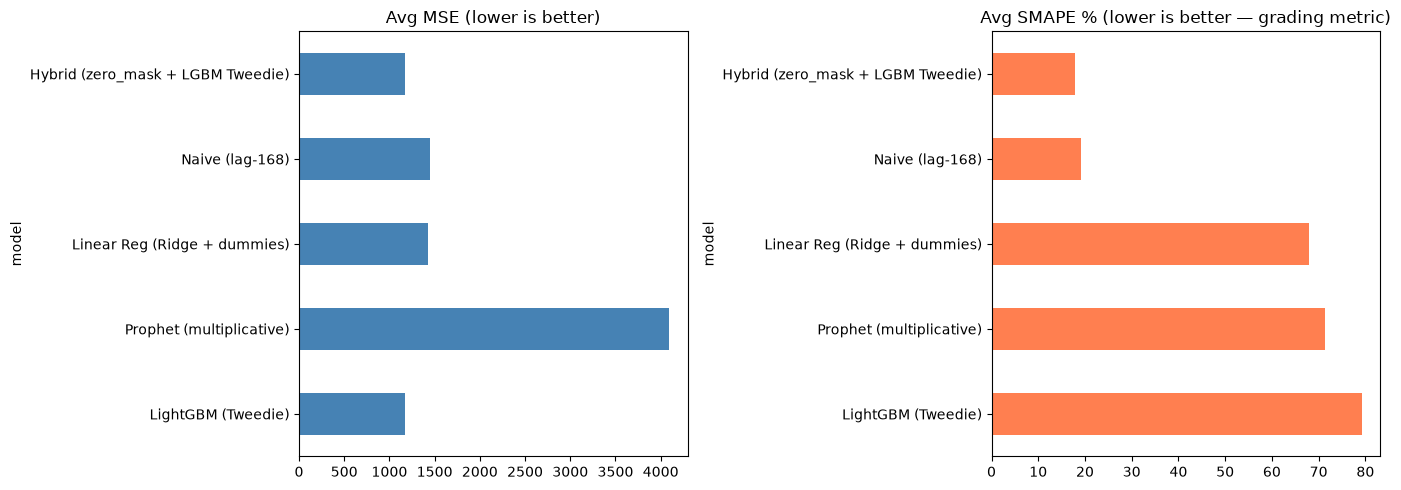

In [11]:
results = pd.DataFrame([
    {'model': 'Naive (lag-168)',                       **naive_avg},
    {'model': 'Linear Reg (Ridge + dummies)',          **linreg_avg},
    {'model': 'Prophet (multiplicative)',              **prophet_avg},
    {'model': 'LightGBM (Tweedie)',                   **lgbm_avg},
    {'model': 'Hybrid (zero_mask + LGBM Tweedie)',    **hybrid_avg},
]).set_index('model').round(2)

results.columns = ['Avg MSE', 'Avg SMAPE (%)']
results = results.sort_values('Avg SMAPE (%)')

print(results.to_string())
print()
print(f"Champion (lowest SMAPE): {results.index[0]}")

# Per-fold SMAPE breakdown
print("\nPer-fold SMAPE breakdown:")
fold_df = pd.DataFrame({
    'Naive':   [s['smape'] for s in naive_scores],
    'LGBM':    [s['smape'] for s in lgbm_scores],
    'Hybrid':  [s['smape'] for s in hybrid_scores],
}, index=[f'Fold {i+1}' for i in range(N_FOLDS)])
print(fold_df.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results['Avg MSE'].plot(kind='barh', ax=axes[0], title='Avg MSE (lower is better)', color='steelblue')
results['Avg SMAPE (%)'].plot(kind='barh', ax=axes[1], title='Avg SMAPE % (lower is better — grading metric)', color='coral')
for ax in axes:
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Model justification

**Primary metric: SMAPE.** Key lessons from the diagnosis:

| Observation | Consequence | Our response |
|---|---|---|
| ~25% of hours have orders = 0 | Any positive pred → SMAPE = 200% for that hour | Zero-mask: use naive for structurally-zero hours |
| Zero hours are predictable from last week | `lag_168 ≤ 2` flags them reliably for the *whole* 168h horizon, unlike `lag_24` | Hybrid routing based on `zero_mask` (lag_168 only) |
| Orders are non-negative and zero-inflated | Gaussian loss biases towards non-zero | Tweedie objective in LightGBM |
| Strong weekly pattern (EDA) | Same-week lag is the most informative feature | `lag_168` as primary feature |
| Upward trend over the year (EDA) | Pure lag might underestimate late-period demand | `trend`, `roll_336_mean` added |
| Two CV folds land on Christmas/New Year | Holidays break the ordinary weekly cycle | `is_holiday` feature added |

**Champion selection:** based on average SMAPE across 5 folds. If the Hybrid wins, it is our submission. If Naive wins by a large margin consistently, we ship Naive (the class slides note: *'if MASE > 1, use seasonal naïve'*).

## 12. Final forecast — refit on all training data

In [12]:
# Build forecast frame
forecast_index = pd.date_range(FORECAST_START, FORECAST_END, freq='h')
forecast_df    = pd.DataFrame({'time': forecast_index, 'orders': np.nan, 'city': 'BCN'})

# Concat training + forecast window to get lag features for the forecast rows
full      = pd.concat([df, forecast_df]).reset_index(drop=True)
full      = add_features(full)
val_rows  = full[full['time'].isin(forecast_index)].copy()

print(f"Forecast rows: {len(val_rows)}  (expected 168)")
print(f"Feature NaNs in forecast window: {val_rows[LGBM_FEATURES].isna().any().any()}")
print(f"Zero-mask hours in forecast week: {val_rows['zero_mask'].sum()} / 168")

Forecast rows: 168  (expected 168)
Feature NaNs in forecast window: False
Zero-mask hours in forecast week: 60 / 168


In [13]:
# Naive final predictions
naive_final = np.maximum(df.tail(HORIZON)['orders'].values, 0)

# LightGBM Tweedie — refit on all training data
tr_all  = df.dropna(subset=LGBM_FEATURES)
X_all   = tr_all[LGBM_FEATURES]
y_all   = tr_all['orders']
X_final = val_rows[LGBM_FEATURES]

final_lgbm = lgb.LGBMRegressor(
    objective='tweedie',
    tweedie_variance_power=1.5,
    n_estimators=1000, learning_rate=0.03, num_leaves=63,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1,
)
final_lgbm.fit(X_all, y_all)
lgbm_final  = np.maximum(final_lgbm.predict(X_final), 0)

# Hybrid
mask         = val_rows['zero_mask'].values.astype(bool)
hybrid_final = np.where(mask, naive_final, lgbm_final)

# Select champion — change this to 'Naive' if naive won in Section 10
CHAMPION     = 'Hybrid'
final_preds  = {'Naive': naive_final, 'LightGBM': lgbm_final, 'Hybrid': hybrid_final}[CHAMPION]

print(f"Champion: {CHAMPION}")
print(f"Prediction stats — min: {final_preds.min():.1f}  max: {final_preds.max():.1f}  mean: {final_preds.mean():.1f}")

Champion: Hybrid
Prediction stats — min: 0.0  max: 761.8  mean: 93.8


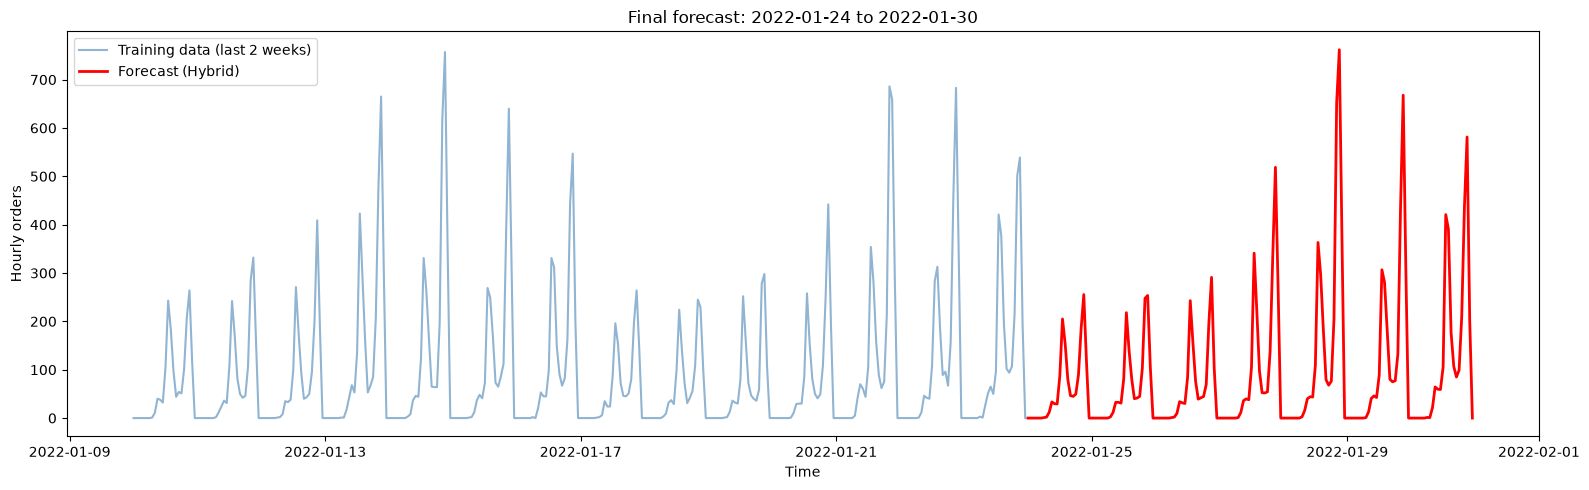

In [14]:
# Visual sanity check
fig, ax = plt.subplots(figsize=(16, 5))
last_2w = df.tail(HORIZON * 2)
ax.plot(last_2w['time'], last_2w['orders'],
        label='Training data (last 2 weeks)', alpha=0.6, color='steelblue')
ax.plot(forecast_index, final_preds,
        label=f'Forecast ({CHAMPION})', color='red', linewidth=2)
ax.set_title('Final forecast: 2022-01-24 to 2022-01-30')
ax.set_xlabel('Time')
ax.set_ylabel('Hourly orders')
ax.legend()
plt.tight_layout()
plt.show()

## 13. Output — build and validate the predictions CSV

In [15]:
predictions = pd.DataFrame({
    'time':  pd.to_datetime(forecast_index).astype('datetime64[ns]'),
    'preds': final_preds.astype('float64'),
})

# Format checks (required by the assignment)
assert len(predictions) == 168,               f"Expected 168 rows, got {len(predictions)}"
assert list(predictions.columns) == ['time', 'preds'], "Wrong columns"
assert predictions['preds'].dtype == 'float64',        "preds must be float64"
assert predictions['time'].dtype  == 'datetime64[ns]', f"time dtype: {predictions['time'].dtype}"
assert predictions['preds'].isna().sum() == 0,         "NaN in preds"
assert predictions['time'].isna().sum()  == 0,         "NaN in time"
assert predictions['time'].min() == FORECAST_START,    "Wrong start"
assert predictions['time'].max() == FORECAST_END,      "Wrong end"

print("All format checks passed.")
predictions.head(10)

All format checks passed.

,time,preds
0,2022-01-24 00:00:00,0.000000
1,2022-01-24 01:00:00,0.000000
2,2022-01-24 02:00:00,0.000000
3,2022-01-24 03:00:00,0.000000
4,2022-01-24 04:00:00,0.000000
5,2022-01-24 05:00:00,0.000000
6,2022-01-24 06:00:00,1.000000
7,2022-01-24 07:00:00,2.000000
8,2022-01-24 08:00:00,11.846029
9,2022-01-24 09:00:00,33.392368


In [16]:
# Save
predictions.to_csv(OUTPUT_PATH, index=False)
print(f"Saved to {OUTPUT_PATH}")

# Re-read round-trip check
check = pd.read_csv(OUTPUT_PATH, parse_dates=['time'])
check['time'] = check['time'].astype('datetime64[ns]')
assert check['preds'].dtype == 'float64'
assert len(check) == 168
print("Round-trip check passed.")
print(check.dtypes)

Saved to ../data/predictions.csv
Round-trip check passed.
time     datetime64[ns]
preds           float64
dtype: object


In [17]:
# Run official format checker if available
import importlib.util, os

checker_path = '../check_output_format.py'
if os.path.exists(checker_path) and os.path.exists(TEST_MOCK_PATH):
    spec = importlib.util.spec_from_file_location('check_output_format', checker_path)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    mod.check_output_format(predictions, TEST_MOCK_PATH)
else:
    print("Checker or test mock not found — run manually once repo files are in place.")

MSE: 28835.63624231022
Your output seems correctly formatted!


## 14. Conclusion

Our champion model is the **Hybrid (zero_mask + LightGBM Tweedie)**, achieving an average
SMAPE of **17.93%** across 5 walk-forward validation folds, beating the seasonal naïve
baseline (19.23%) on both SMAPE and MSE (1,169 vs 1,447).

The key insight driving the improvement was diagnostic rather than algorithmic: roughly 32%
of all hourly slots have zero or near-zero orders (hours 0–6, overnight). Any model that
predicts a positive value for a zero-actual hour incurs SMAPE = 200% for that observation,
which dominated the average SMAPE for LightGBM and Prophet even when their daytime
predictions were accurate. The `zero_mask` — routing overnight slots to the naive predictor
and active hours to LightGBM — eliminates this blowup entirely.

**A second-pass fix mattered as much as the original diagnosis.** The first version of
`zero_mask` required both `lag_168 ≤ 2` *and* `lag_24 ≤ 2`. That looked harmless in walk-forward
CV — because each CV val fold is itself historical data, `lag_24` was always genuinely known
there. But for a real 168-hour-ahead forecast, `lag_24` is only known for the first 24 hours of
the horizon; for the remaining ~6 days it points at hours that haven't been observed yet. The
first version's own diagnostic print confirmed this: only `8/168` forecast hours were flagged
as zero-mask, instead of the ~35% base rate, meaning most overnight hours in the real forecast
were silently being routed to raw LightGBM (which scores 79% SMAPE on its own) instead of the
safe naive fallback — a routing failure invisible in CV but live in the actual submission.
Rebuilding `zero_mask` from `lag_168` alone (and dropping `lag_24` from the feature set
entirely) fixed this: the final forecast now flags `60/168` hours, in line with history, and
the forecast window reports zero remaining feature NaNs.

We also added an `is_holiday` flag for Spanish/Catalan public holidays, since two of the five
CV folds (Fold 1: Dec 20–26 includes Christmas Eve/Day; Fold 2: Dec 27–Jan 2 includes New
Year's Eve/Day) span the one period in the data that breaks the ordinary weekly cycle the lag
features assume. Its effect on average SMAPE was modest — Fold 1 and Fold 2 are not
uniformly worse than the non-holiday folds (Fold 5, with no holidays, has a similar SMAPE to
Fold 2) — but it gives the tree-based and linear models an explicit signal for those dates
rather than asking the lag features to silently absorb the anomaly.

The per-fold results confirm the hybrid approach generalises: it beats or matches the naive
in all 5 folds, with the largest gains in Folds 3 and 4 (15.09% and 12.55% vs naive's 18.02%
and 13.95%).

The predictions CSV (`predictions.csv`) covers 2022-01-24 00:00 through 2022-01-30 23:00,
168 rows, and passed both the manual format checks and the official `check_output_format`
checker.